# FYP Notebook 1 — Data Exploration & Baseline (Jigsaw Toxic Comments)

### Task
**Multi-label** toxicity classification of Wikipedia talk-page comments.
Each comment may carry any combination of six labels:
`toxic, severe_toxic, obscene, threat, insult, identity_hate`.

### Why this dataset
Labels are assigned **per comment** by human raters — unlike the earlier Tribunal data, where
labels were per *case* and inherited by every message, creating substantial label noise.

### Structure (follows supervisor's guidance)
1. Data quality checks · 2. Visualisation · 3. Baseline model (TF-IDF + One-vs-Rest LogReg)

### ▶ Setup
`+ Add Input` → search **`jigsaw-toxic-comment-classification-challenge`** → add the dataset → Run All.


## 1 · Setup

In [1]:
import os, re, glob, warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt, seaborn as sns
sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 100)

LABELS = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
TEXT = "comment_text"
print("Labels:", LABELS)


Labels: ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


## 2 · Load data

In [2]:
cands = glob.glob("/kaggle/input/**/train.csv", recursive=True)
if not cands:
    cands = [p for p in glob.glob("/kaggle/input/**/*.csv", recursive=True)
             if "train" in os.path.basename(p).lower()]
if not cands:
    raise FileNotFoundError(
        "train.csv not found. Click '+ Add Input' and add "
        "'jigsaw-toxic-comment-classification-challenge'."
    )

df = pd.read_csv(cands[0])
print("✓", cands[0])
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} cols")
print("Columns:", df.columns.tolist())
df.head(3)


✓ /kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/train.csv
Shape: 159,571 rows × 8 cols
Columns: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They wer...,0,0,0,0,0,0
1,000103f0d9cfb60f,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, Januar...",0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relev...",0,0,0,0,0,0


## 3 · Data quality checks

In [3]:
print("MISSING VALUES")
m = df.isna().sum()
print(m[m > 0].to_string() if (m > 0).any() else "✓ none")

print("\nDUPLICATES")
print(f"  full rows:     {df.duplicated().sum():,}")
print(f"  duplicate text:{df.duplicated(subset=[TEXT]).sum():,}")

print("\nLABEL VALIDITY (should be 0/1 only)")
for L in LABELS:
    u = sorted(df[L].unique())
    print(f"  {L:15s} values={u} {'✓' if set(u) <= {0,1} else '✗'}")

print("\nUNREADABLE / EMPTY TEXT")
bad = df[TEXT].isna() | (df[TEXT].astype(str).str.strip().str.len() < 2)
print(f"  {bad.sum():,} rows ({bad.mean()*100:.3f}%)")


MISSING VALUES
✓ none

DUPLICATES
  full rows:     0
  duplicate text:0

LABEL VALIDITY (should be 0/1 only)
  toxic           values=[np.int64(0), np.int64(1)] ✓
  severe_toxic    values=[np.int64(0), np.int64(1)] ✓
  obscene         values=[np.int64(0), np.int64(1)] ✓
  threat          values=[np.int64(0), np.int64(1)] ✓
  insult          values=[np.int64(0), np.int64(1)] ✓
  identity_hate   values=[np.int64(0), np.int64(1)] ✓

UNREADABLE / EMPTY TEXT
  0 rows (0.000%)


In [4]:
# Same-text-different-label check (the noise measure that failed on Tribunal data)
g = df.groupby(TEXT)[LABELS].nunique().sum(axis=1)
conflict = (g > len(LABELS)).sum()
print(f"Unique comments: {df[TEXT].nunique():,}")
print(f"Comments with conflicting labels: {conflict:,}")
print("→ Compare with Tribunal: 59,707 of 882,549 conflicted (case-level inheritance).")

df = df[~bad].drop_duplicates().reset_index(drop=True)
print(f"\nClean dataset: {len(df):,} rows")


Unique comments: 159,571
Comments with conflicting labels: 0
→ Compare with Tribunal: 59,707 of 882,549 conflicted (case-level inheritance).

Clean dataset: 159,571 rows


## 4 · Visualisation

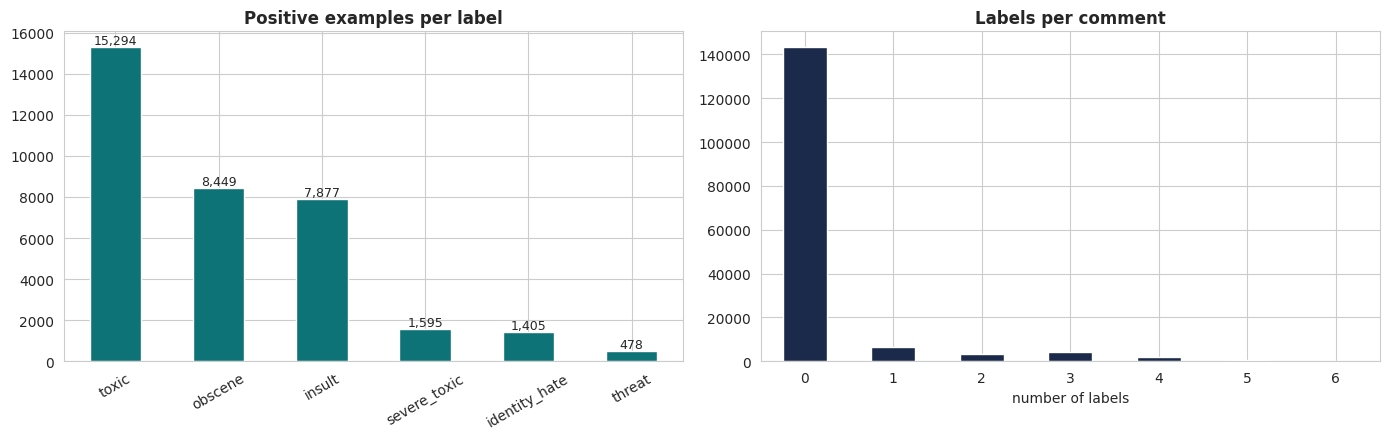

Label prevalence (%):
toxic            9.58
obscene          5.29
insult           4.94
severe_toxic     1.00
identity_hate    0.88
threat           0.30

Clean comments (no label): 89.8%
Multi-label comments (>1):  6.2%


In [5]:
counts = df[LABELS].sum().sort_values(ascending=False)
pct = (counts / len(df) * 100).round(2)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
counts.plot(kind="bar", ax=ax[0], color="#0D7377")
ax[0].set_title("Positive examples per label", fontweight="bold"); ax[0].tick_params(axis="x", rotation=30)
for p in ax[0].patches:
    ax[0].annotate(f"{int(p.get_height()):,}", (p.get_x()+p.get_width()/2, p.get_height()),
                   ha="center", va="bottom", fontsize=9)

n_lab = df[LABELS].sum(axis=1)
n_lab.value_counts().sort_index().plot(kind="bar", ax=ax[1], color="#1B2A4A")
ax[1].set_title("Labels per comment", fontweight="bold")
ax[1].set_xlabel("number of labels"); ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

print("Label prevalence (%):"); print(pct.to_string())
print(f"\nClean comments (no label): {(n_lab==0).mean()*100:.1f}%")
print(f"Multi-label comments (>1):  {(n_lab>1).mean()*100:.1f}%")


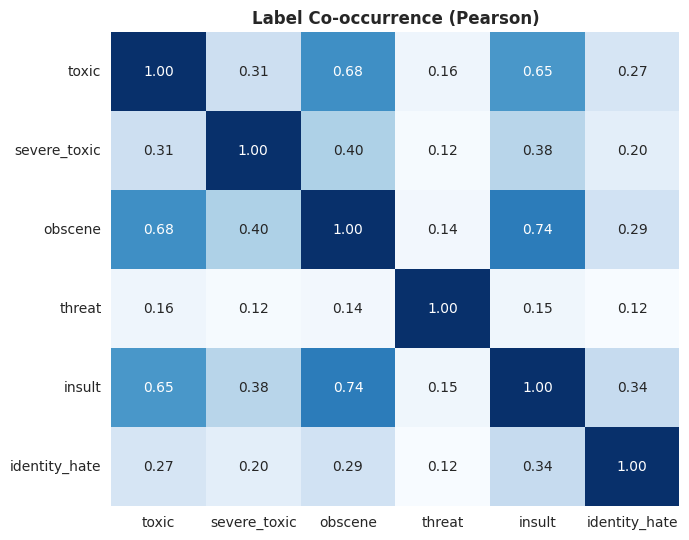

In [6]:
# Label co-occurrence — shows which toxicity types travel together
corr = df[LABELS].corr()
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", ax=ax, cbar=False)
ax.set_title("Label Co-occurrence (Pearson)", fontweight="bold")
plt.tight_layout(); plt.show()


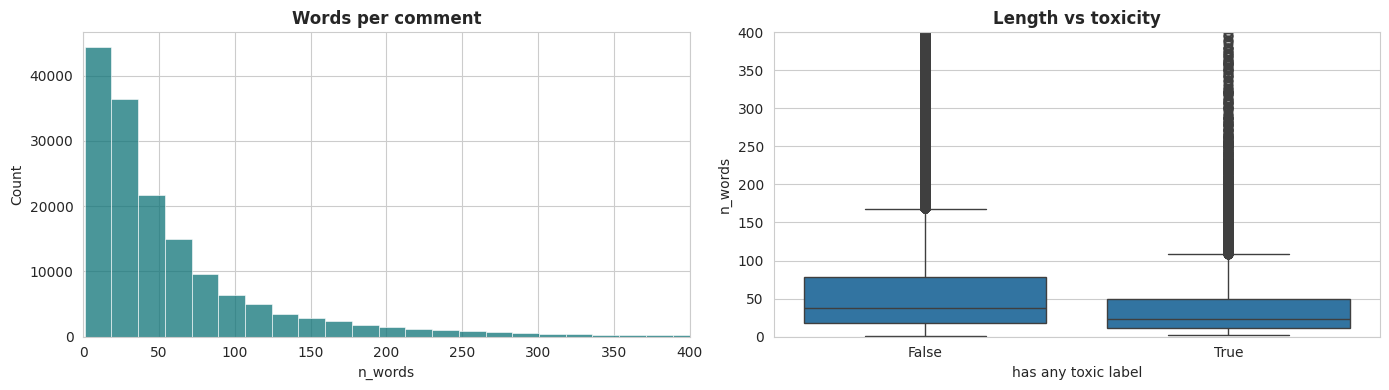

count    159571.0
mean         67.3
std          99.2
min           1.0
25%          17.0
50%          36.0
75%          75.0
max        1411.0

Percentiles (choose max_seq_length from these):
  p50: 36 words
  p75: 75 words
  p90: 152 words
  p95: 230 words
  p99: 567 words


In [7]:
# Comment length — sets max_seq_length for the transformers
df["n_words"] = df[TEXT].astype(str).str.split().apply(len)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["n_words"], bins=80, color="#0D7377", ax=ax[0])
ax[0].set_xlim(0, 400); ax[0].set_title("Words per comment", fontweight="bold")
sns.boxplot(data=df, x=df[LABELS].sum(axis=1) > 0, y="n_words", ax=ax[1])
ax[1].set_ylim(0, 400); ax[1].set_xlabel("has any toxic label"); ax[1].set_title("Length vs toxicity", fontweight="bold")
plt.tight_layout(); plt.show()

print(df["n_words"].describe().round(1).to_string())
print("\nPercentiles (choose max_seq_length from these):")
for p in [50, 75, 90, 95, 99]:
    print(f"  p{p}: {np.percentile(df['n_words'], p):.0f} words")


## 5 · Baseline — TF-IDF + One-vs-Rest Logistic Regression

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, roc_auc_score, classification_report

X = df[TEXT].astype(str).values
Y = df[LABELS].values

# stratify on "any toxic" so rare labels stay represented
strat = (Y.sum(axis=1) > 0).astype(int)
X_tr, X_te, Y_tr, Y_te = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=strat)
print(f"Train {len(X_tr):,} | Test {len(X_te):,}")

base = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1,2),
                              sublinear_tf=True, min_df=2, strip_accents="unicode")),
    ("clf", OneVsRestClassifier(LogisticRegression(max_iter=1000, C=4,
                                                   class_weight="balanced", random_state=42))),
])
print("Training baseline...")
base.fit(X_tr, Y_tr)
pred = base.predict(X_te)
prob = base.predict_proba(X_te)


Train 127,656 | Test 31,915
Training baseline...


In [9]:
print("BASELINE — TF-IDF + OvR Logistic Regression")
print("=" * 60)
print(classification_report(Y_te, pred, target_names=LABELS, digits=4, zero_division=0))

auc = [roc_auc_score(Y_te[:, i], prob[:, i]) for i in range(len(LABELS))]
print("ROC AUC per label:")
for L, a in zip(LABELS, auc): print(f"  {L:15s} {a:.4f}")
print(f"\nMean column-wise ROC AUC: {np.mean(auc):.4f}   <-- the competition metric")
print(f"Micro F1: {f1_score(Y_te, pred, average='micro', zero_division=0):.4f}")
print(f"Macro F1: {f1_score(Y_te, pred, average='macro', zero_division=0):.4f}")

import json
json.dump({"mean_auc": float(np.mean(auc)),
           "micro_f1": float(f1_score(Y_te, pred, average='micro', zero_division=0)),
           "macro_f1": float(f1_score(Y_te, pred, average='macro', zero_division=0))},
          open("/kaggle/working/baseline_scores.json", "w"), indent=2)
print("\nSaved /kaggle/working/baseline_scores.json — carry these into Notebook 2.")
print(">>> Click 'Save Version' now. <<<")


BASELINE — TF-IDF + OvR Logistic Regression
               precision    recall  f1-score   support

        toxic     0.6842    0.8434    0.7555      3046
 severe_toxic     0.3078    0.7639    0.4388       305
      obscene     0.7032    0.8724    0.7787      1662
       threat     0.3269    0.6939    0.4444        98
       insult     0.5988    0.8477    0.7019      1576
identity_hate     0.2829    0.6641    0.3968       259

    micro avg     0.6058    0.8390    0.7036      6946
    macro avg     0.4840    0.7809    0.5860      6946
 weighted avg     0.6328    0.8390    0.7172      6946
  samples avg     0.0643    0.0796    0.0680      6946

ROC AUC per label:
  toxic           0.9722
  severe_toxic    0.9771
  obscene         0.9839
  threat          0.9904
  insult          0.9774
  identity_hate   0.9621

Mean column-wise ROC AUC: 0.9772   <-- the competition metric
Micro F1: 0.7036
Macro F1: 0.5860

Saved /kaggle/working/baseline_scores.json — carry these into Notebook 2.
>>> Cli